In [2]:
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
from PIL import Image
from io import BytesIO
import torch
from itertools import islice
from sentence_transformers import SentenceTransformer, util
from transformers import BlipProcessor, BlipForConditionalGeneration

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Fetch Image

In [13]:
def fetch_api_data(url):
    """
    Fetch JSON data from a given API URL with robust error handling.
    """
    # Validate input type
    if not isinstance(url, str) or not url.startswith("http"):
        raise ValueError("URL must be a valid string starting with http or https.")

    try:
        response = requests.get(url, timeout=10)  # 10‑second timeout for safety
        response.raise_for_status()  # Raises HTTPError for bad HTTP codes

        # Try decoding JSON
        try:
            return response.json()
        except ValueError:
            raise ValueError("API response is not valid JSON.")

    except requests.exceptions.Timeout:
        raise TimeoutError("The request timed out. Try again later.")
    except requests.exceptions.ConnectionError:
        raise ConnectionError("Network connection error.")
    except requests.exceptions.HTTPError as http_err:
        raise RuntimeError(f"HTTP error occurred: {http_err}")
    except Exception as err:
        raise RuntimeError(f"Unexpected error: {err}")

In [14]:
api_url = "https://api.imgflip.com/get_memes"

try:
    data = fetch_api_data(api_url)
    print("API Response:")
    print(data)
except Exception as e:
    print(f"Error: {e}")

API Response:
{'success': True, 'data': {'memes': [{'id': '181913649', 'name': 'Drake Hotline Bling', 'url': 'https://i.imgflip.com/30b1gx.jpg', 'width': 1200, 'height': 1200, 'box_count': 2, 'captions': 1562000}, {'id': '87743020', 'name': 'Two Buttons', 'url': 'https://i.imgflip.com/1g8my4.jpg', 'width': 600, 'height': 908, 'box_count': 3, 'captions': 1214750}, {'id': '112126428', 'name': 'Distracted Boyfriend', 'url': 'https://i.imgflip.com/1ur9b0.jpg', 'width': 1200, 'height': 800, 'box_count': 3, 'captions': 1189250}, {'id': '217743513', 'name': 'UNO Draw 25 Cards', 'url': 'https://i.imgflip.com/3lmzyx.jpg', 'width': 500, 'height': 494, 'box_count': 2, 'captions': 661500}, {'id': '124822590', 'name': 'Left Exit 12 Off Ramp', 'url': 'https://i.imgflip.com/22bdq6.jpg', 'width': 804, 'height': 767, 'box_count': 3, 'captions': 743250}, {'id': '222403160', 'name': 'Bernie I Am Once Again Asking For Your Support', 'url': 'https://i.imgflip.com/3oevdk.jpg', 'width': 750, 'height': 750, '

In [15]:
with open("data.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

In [ ]:
for meme in data.get("data", {}).get("memes", []):
    image_url = meme.get("url")
    if image_url:
        try:
            image_response = requests.get(image_url, timeout=10)
            image_response.raise_for_status()
            print(f"Successfully fetched image from {image_url}")
            
            # Define the directory
            directory = 'images/'

            # Create directory if it doesn't exist
            if not os.path.exists(directory):
                os.makedirs(directory)

            image = Image.open(BytesIO(image_response.content))
            image.save(f"{directory}{meme.get('id')}.jpg")
            
            print(f"Saved image {meme.get('id')}.jpg to {directory}")
                      
        except requests.exceptions.RequestException as e:
            print(f"Failed to fetch image from {image_url}: {e}")
        except Exception as e:
            print(f"Failed to save image {meme.get('id')}.jpg: {e}")

In [17]:
with open("data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Vision-Language Model

In [4]:
context = {f"{meme.get('id')}.jpg": [meme.get('name')] for meme in data.get("data", {}).get("memes", [])}
context
    

{'181913649.jpg': ['Drake Hotline Bling'],
 '87743020.jpg': ['Two Buttons'],
 '112126428.jpg': ['Distracted Boyfriend'],
 '217743513.jpg': ['UNO Draw 25 Cards'],
 '124822590.jpg': ['Left Exit 12 Off Ramp'],
 '222403160.jpg': ['Bernie I Am Once Again Asking For Your Support'],
 '131087935.jpg': ['Running Away Balloon'],
 '252600902.jpg': ['Always Has Been'],
 '135256802.jpg': ['Epic Handshake'],
 '322841258.jpg': ['Anakin Padme 4 Panel'],
 '4087833.jpg': ['Waiting Skeleton'],
 '131940431.jpg': ["Gru's Plan"],
 '97984.jpg': ['Disaster Girl'],
 '80707627.jpg': ['Sad Pablo Escobar'],
 '91538330.jpg': ['X, X Everywhere'],
 '188390779.jpg': ['Woman Yelling At Cat'],
 '102156234.jpg': ['Mocking Spongebob'],
 '129242436.jpg': ['Change My Mind'],
 '438680.jpg': ['Batman Slapping Robin'],
 '309868304.jpg': ['Trade Offer'],
 '101470.jpg': ['Ancient Aliens'],
 '124055727.jpg': ["Y'all Got Any More Of That"],
 '93895088.jpg': ['Expanding Brain'],
 '247375501.jpg': ['Buff Doge vs. Cheems'],
 '505705

In [5]:
# 1. Initialize the Vision-Language Model and Processor
# This model is pre-trained to understand images and generate text descriptions
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

IMAGE_DIR = "images"

print("Analyzing memes...\n")

# 2. Loop through your images folder
for img_name in os.listdir(IMAGE_DIR):
    if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue
        
    img_path = os.path.join(IMAGE_DIR, img_name)
    raw_image = Image.open(img_path).convert('RGB')

    # 3. Process the image for the model
    inputs = processor(raw_image, return_tensors="pt")

    # 4. Generate the caption text
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    
    context[img_name].append(caption)  # Store the generated caption in the context dictionary
    
    # 5. Output what the model "sees"
    print(f"Meme: {img_name}")
    print(f"Description: {caption}")
    print("-" * 40)

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 22156.64it/s]


Analyzing memes...



c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\generation\utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Meme: 100777631.jpg
Description: a cartoon character with glasses and a butterfly
----------------------------------------
Meme: 101288.jpg
Description: a woman and child are sitting on the ground
----------------------------------------
Meme: 101470.jpg
Description: a man in a suit and tie is talking
----------------------------------------
Meme: 101956210.jpg
Description: a woman ' s ear with a small amount of hair
----------------------------------------
Meme: 102156234.jpg
Description: a cartoon character with a capt that reads, when you ' reting your name, you ' re
----------------------------------------
Meme: 1035805.jpg
Description: a comic strip strip strip strip strip strip strip strip strip strip strip strip strip strip strip strip strip strip
----------------------------------------
Meme: 110133729.jpg
Description: spider and spider in spider - man
----------------------------------------
Meme: 110163934.jpg
Description: a man and woman laying in bed
-----------------------

In [6]:
with open("context.json", "w", encoding="utf-8") as f:
    json.dump(context, f, ensure_ascii=False, indent=4)

In [20]:
def print_meme(img_name):
    print(f"Displaying {img_name} with context: {context[img_name]}")
    
    try:
        img = mpimg.imread(os.path.join(IMAGE_DIR, img_name))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Failed to display image {img_name}: {e}")

Displaying 181913649.jpg with context: ['Drake Hotline Bling', "drake - ' s new video for ' the game '"]


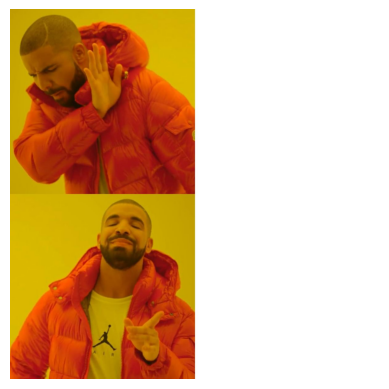

Displaying 87743020.jpg with context: ['Two Buttons', 'a comic strip strip strip strip strip comics, funny comics, funny comics, funny comics, funny comics']


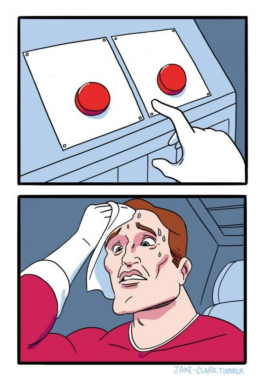

Displaying 112126428.jpg with context: ['Distracted Boyfriend', 'three young people walking down the street']


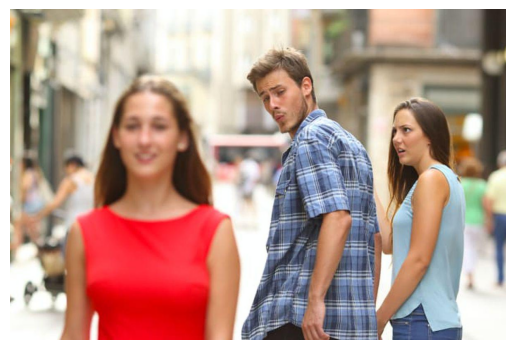

Displaying 217743513.jpg with context: ['UNO Draw 25 Cards', 'a man playing cards with a card in his hand']


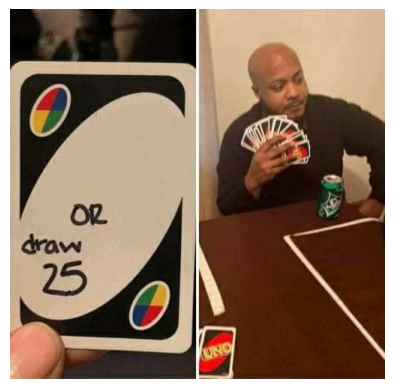

Displaying 124822590.jpg with context: ['Left Exit 12 Off Ramp', 'a car is driving under a bridge']


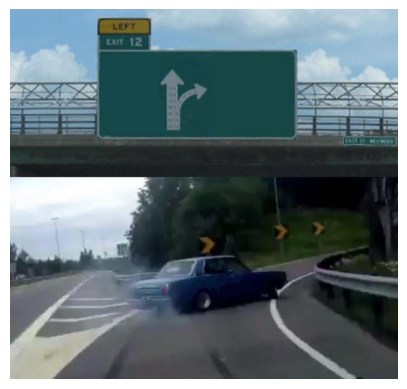

Displaying 222403160.jpg with context: ['Bernie I Am Once Again Asking For Your Support', 'a man in a park with a snow covered ground']


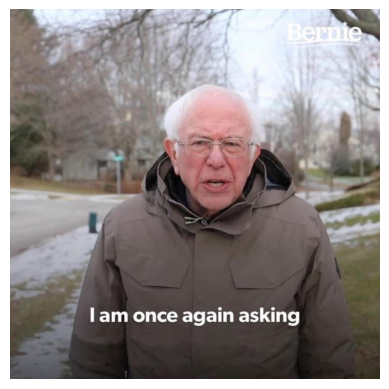

In [10]:
for img_name in dict(islice(context.items(), 6)):
    print(f"Displaying {img_name} with context: {context[img_name]}")
    
    try:
        img = mpimg.imread(os.path.join(IMAGE_DIR, img_name))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Failed to display image {img_name}: {e}")

# Sentence Transformer

In [12]:
context

{'181913649.jpg': ['Drake Hotline Bling',
  "drake - ' s new video for ' the game '"],
 '87743020.jpg': ['Two Buttons',
  'a comic strip strip strip strip strip comics, funny comics, funny comics, funny comics, funny comics'],
 '112126428.jpg': ['Distracted Boyfriend',
  'three young people walking down the street'],
 '217743513.jpg': ['UNO Draw 25 Cards',
  'a man playing cards with a card in his hand'],
 '124822590.jpg': ['Left Exit 12 Off Ramp', 'a car is driving under a bridge'],
 '222403160.jpg': ['Bernie I Am Once Again Asking For Your Support',
  'a man in a park with a snow covered ground'],
 '131087935.jpg': ['Running Away Balloon',
  'a cartoon character is holding a yellow balloon'],
 '252600902.jpg': ['Always Has Been',
  'two astronauts in space with earth in the background'],
 '135256802.jpg': ['Epic Handshake',
  'two hands in the air greeting card for sale by person'],
 '322841258.jpg': ['Anakin Padme 4 Panel', 'the hungers are all smiles'],
 '4087833.jpg': ['Waiting Sk

In [18]:
with open("meme_data.json", "r", encoding="utf-8") as f:
    meme_data = json.load(f)

In [23]:
new_data = data.get("data", {}).get("memes", [])

new_meme_data = [(m.get("file"), d.get("url")) for m in meme_data for d in new_data if m.get("file")[:-4] == d.get("id")]

In [24]:
new_meme_data

[('181913649.jpg', 'https://i.imgflip.com/30b1gx.jpg'),
 ('87743020.jpg', 'https://i.imgflip.com/1g8my4.jpg'),
 ('112126428.jpg', 'https://i.imgflip.com/1ur9b0.jpg'),
 ('217743513.jpg', 'https://i.imgflip.com/3lmzyx.jpg'),
 ('124822590.jpg', 'https://i.imgflip.com/22bdq6.jpg'),
 ('222403160.jpg', 'https://i.imgflip.com/3oevdk.jpg'),
 ('131087935.jpg', 'https://i.imgflip.com/261o3j.jpg'),
 ('252600902.jpg', 'https://i.imgflip.com/46e43q.png'),
 ('135256802.jpg', 'https://i.imgflip.com/28j0te.jpg'),
 ('322841258.jpg', 'https://i.imgflip.com/5c7lwq.png'),
 ('4087833.jpg', 'https://i.imgflip.com/2fm6x.jpg'),
 ('131940431.jpg', 'https://i.imgflip.com/26jxvz.jpg'),
 ('97984.jpg', 'https://i.imgflip.com/23ls.jpg'),
 ('80707627.jpg', 'https://i.imgflip.com/1c1uej.jpg'),
 ('91538330.jpg', 'https://i.imgflip.com/1ihzfe.jpg'),
 ('188390779.jpg', 'https://i.imgflip.com/345v97.jpg'),
 ('102156234.jpg', 'https://i.imgflip.com/1otk96.jpg'),
 ('129242436.jpg', 'https://i.imgflip.com/24y43o.jpg'),
 ('4

In [26]:
new_meme_data = [m.update({"url": n[1]}) or m for m in meme_data for n in new_meme_data if m.get("file") == n[0]]

In [27]:
new_meme_data

[{'file': '181913649.jpg',
  'title': 'Drake Hotline Bling',
  'caption': "drake - ' s new video for ' the game '",
  'url': 'https://i.imgflip.com/30b1gx.jpg'},
 {'file': '87743020.jpg',
  'title': 'Two Buttons',
  'caption': 'a comic strip strip strip strip strip comics, funny comics, funny comics, funny comics, funny comics',
  'url': 'https://i.imgflip.com/1g8my4.jpg'},
 {'file': '112126428.jpg',
  'title': 'Distracted Boyfriend',
  'caption': 'three young people walking down the street',
  'url': 'https://i.imgflip.com/1ur9b0.jpg'},
 {'file': '217743513.jpg',
  'title': 'UNO Draw 25 Cards',
  'caption': 'a man playing cards with a card in his hand',
  'url': 'https://i.imgflip.com/3lmzyx.jpg'},
 {'file': '124822590.jpg',
  'title': 'Left Exit 12 Off Ramp',
  'caption': 'a car is driving under a bridge',
  'url': 'https://i.imgflip.com/22bdq6.jpg'},
 {'file': '222403160.jpg',
  'title': 'Bernie I Am Once Again Asking For Your Support',
  'caption': 'a man in a park with a snow cove

In [28]:
with open('meme_data.json', 'w', encoding='utf-8') as f:
    json.dump(new_meme_data, f, ensure_ascii=False, indent=4)

In [5]:
meme_data = []
for file in context:
    try:
        if len(context[file]) < 2:
            raise IndexError("Context does not contain enough elements for title and caption.")
        meme_data.append({"file": file, "title": context[file][0], "caption": context[file][1]})
    except IndexError:
        print(f"Error occurred while processing file: {file}")

Error occurred while processing file: 221578498.jpg


In [6]:
with open("meme_data.json", "w", encoding="utf-8") as f:
    json.dump(meme_data, f, ensure_ascii=False, indent=4)

In [18]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

search_corpus = [f"{m['title']}. Description: {m['caption']}" for m in meme_data]
corpus_embeddings = embedder.encode(search_corpus, convert_to_tensor=True)

def search_memes(query, top_k=3):
    print(f"\nQuery: '{query}'")
    
    # Vectorize the user's input query
    query_embedding = embedder.encode(query, convert_to_tensor=True)
    
    # Calculate similarity scores (Cosine Similarity)
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    
    # Sort scores in descending order (Fix: accessing attributes explicitly)
    top_results = torch.topk(cos_scores, k=min(top_k, len(meme_data)))
    scores = top_results.values
    indices = top_results.indices
    
    # Print out rankings
    for score, idx in zip(scores, indices):
        meme = meme_data[idx]
        print(f" -> Match Score: {score.item():.4f}")
        print(f"    File: {meme['file']}")
        print(f"    Meme Name: {meme['title']}")
        print(f"    VLM Context: {meme['caption']}\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8241.85it/s]


In [19]:
search_memes("A guy looking at another girl while walking with his girlfriend")
search_memes("Someone sitting lonely outside by himself")
search_memes("An animal shocked with its mouth open wide")


Query: 'A guy looking at another girl while walking with his girlfriend'
 -> Match Score: 0.4146
    File: 112126428.jpg
    Meme Name: Distracted Boyfriend
    VLM Context: three young people walking down the street

 -> Match Score: 0.3096
    File: 110163934.jpg
    Meme Name: I Bet He's Thinking About Other Women
    VLM Context: a man and woman laying in bed

 -> Match Score: 0.3043
    File: 354700819.jpg
    Meme Name: Two guys on a bus
    VLM Context: a cartoon depicting a bus driver and a passenger


Query: 'Someone sitting lonely outside by himself'
 -> Match Score: 0.3926
    File: 80707627.jpg
    Meme Name: Sad Pablo Escobar
    VLM Context: a man sitting on a swing in a park

 -> Match Score: 0.3824
    File: 27813981.jpg
    Meme Name: Hide the Pain Harold
    VLM Context: a man sitting at a desk with a laptop and holding a cup

 -> Match Score: 0.3730
    File: 6235864.jpg
    Meme Name: Finding Neverland
    VLM Context: a man sitting on a bench with a little boy


Q

In [25]:
search_memes("something about math")


Query: 'something about math'
 -> Match Score: 0.1906
    File: 360597639.jpg
    Meme Name: whe i'm in a competition and my opponent is
    VLM Context: when you ' re - when you ' re - when you ' re - when you ' re -

 -> Match Score: 0.1898
    File: 131940431.jpg
    Meme Name: Gru's Plan
    VLM Context: a cartoon character with a lot of emotions

 -> Match Score: 0.1843
    File: 91538330.jpg
    Meme Name: X, X Everywhere
    VLM Context: toy story 2 - woody and buzz



Displaying 360597639.jpg with context: ["whe i'm in a competition and my opponent is", "when you ' re - when you ' re - when you ' re - when you ' re -"]


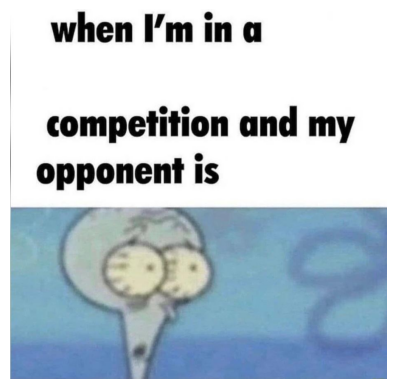

In [26]:
print_meme('360597639.jpg')

In [22]:
# Save the model weights to a local folder
embedder.save("./my_local_model")

# Save the pre-calculated meme vectors (embeddings) to a file
torch.save(corpus_embeddings, "corpus_embeddings.pt")

print("Model and vector database saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 15.90it/s]

Model and vector database saved successfully!


In [ ]:

context_v2 = [
    
]